# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


The data set i will be using is USA_cars_datasets.csv. The target Feature is going to be price, compared to Manufactured year, Mileage, brand, title status, and color.

Features:
Price	
Years	
Brand	
Model	
Color	
State/City	
Mileage	
Vin	
Title Status	
Lot	
serial number 
Condition	

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px

cardf = pd.read_csv('USA_cars_datasets.csv')
cardf.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


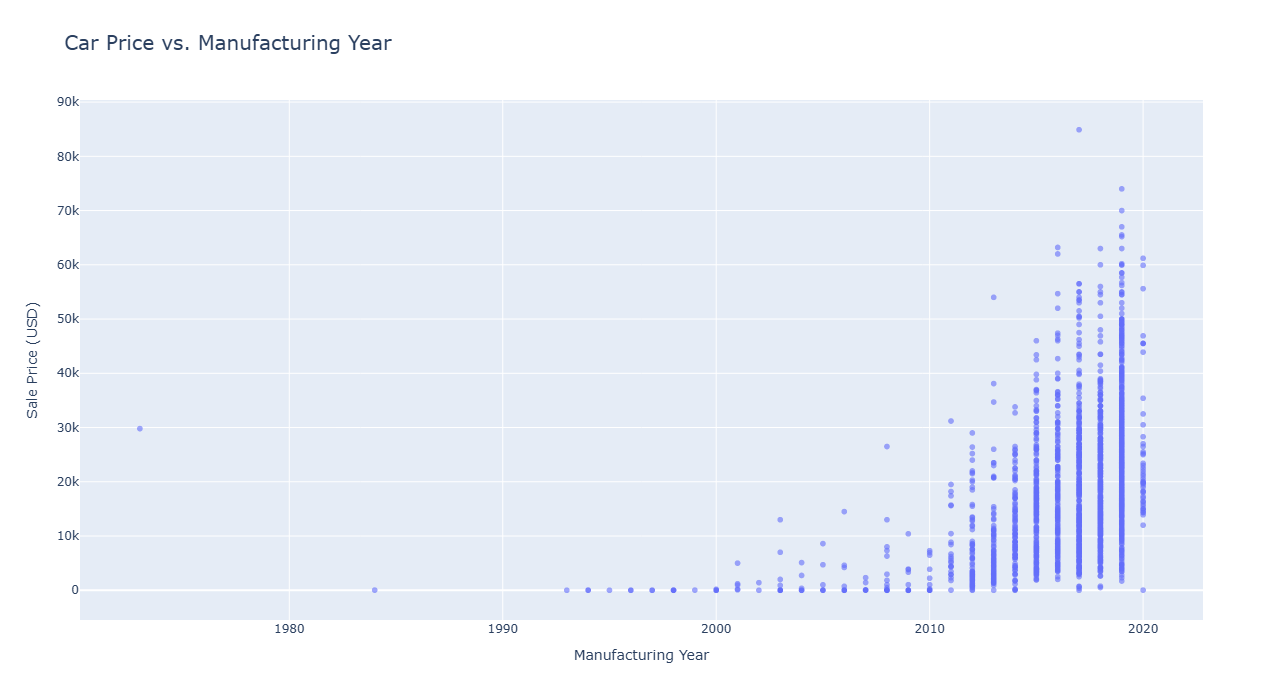

In [8]:


# Create a cleaner 'Age' column for easier reading
cardf['Age'] = 2025 - cardf['year']

# Interactive scatter plot with regression trend line
fig1 = px.scatter(
    cardf, 
    x='year', 
    y='price',
    #trendline='ols',                    # ordinary least squares regression line
    opacity=0.6,
    hover_data=['brand', 'model', 'mileage', 'Age'],   # extra info on hover
    title='Car Price vs. Manufacturing Year',
    labels={'year': 'Manufacturing Year', 
            'price': 'Price (USD)'}
)

fig1.update_layout(
    height=700,
    title_font_size=20,
    xaxis_title='Manufacturing Year',
    yaxis_title='Sale Price (USD)'
)

fig1.show()

Newer cars have a higher Sale Price, but there is a significant decline in value after 20001 which showes that cars older than 25 tend to loose all their value.

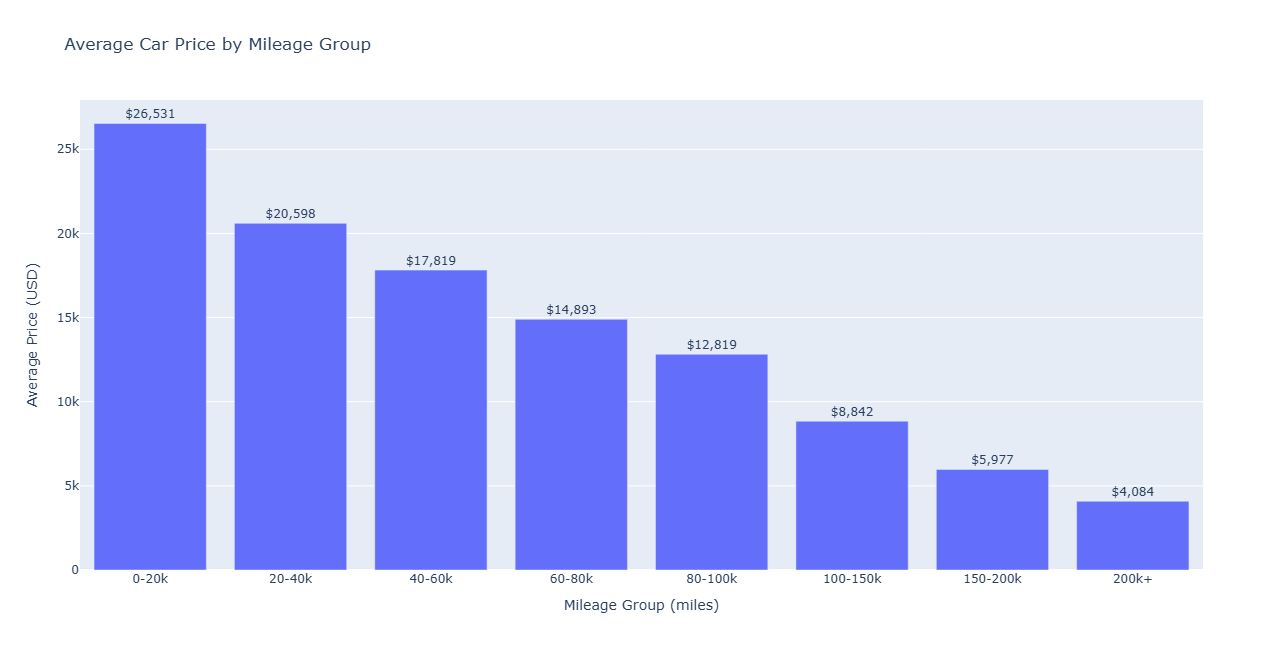

In [31]:
# Create mileage bins for a cleaner "bar-like" view
cardf['Mileage_Group'] = pd.cut(
    cardf['mileage'],
    bins=[0, 20000, 40000, 60000, 80000, 100000, 150000, 200000, cardf['mileage'].max()],
    labels=['0-20k', '20-40k', '40-60k', '60-80k', '80-100k', '100-150k', '150-200k', '200k+']
)

avg_price_by_mileage = cardf.groupby('Mileage_Group', observed=True)['price'].mean().reset_index()

fig_bar = px.bar(
    avg_price_by_mileage,
    x='Mileage_Group',
    y='price',
    title='Average Car Price by Mileage Group',
    labels={'Mileage_Group': 'Mileage Group (miles)', 
            'price': 'Average Price (USD)'},
    text='price'
)

fig_bar.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig_bar.update_layout(height=650)
fig_bar.show()

The fewer miles your vehicle has the more its worth and there is a steady decline showing that you loose roughly $4,000 every 20k miles you put on the vehicle.

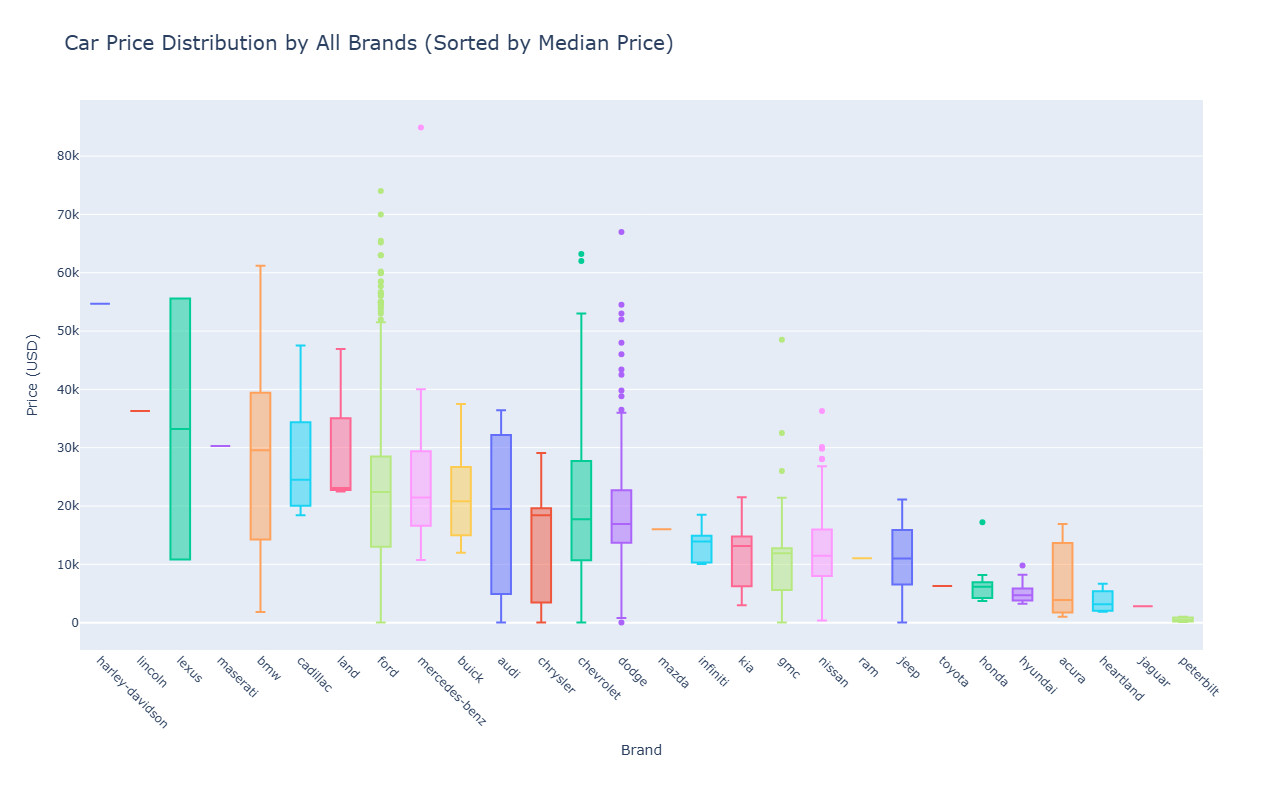

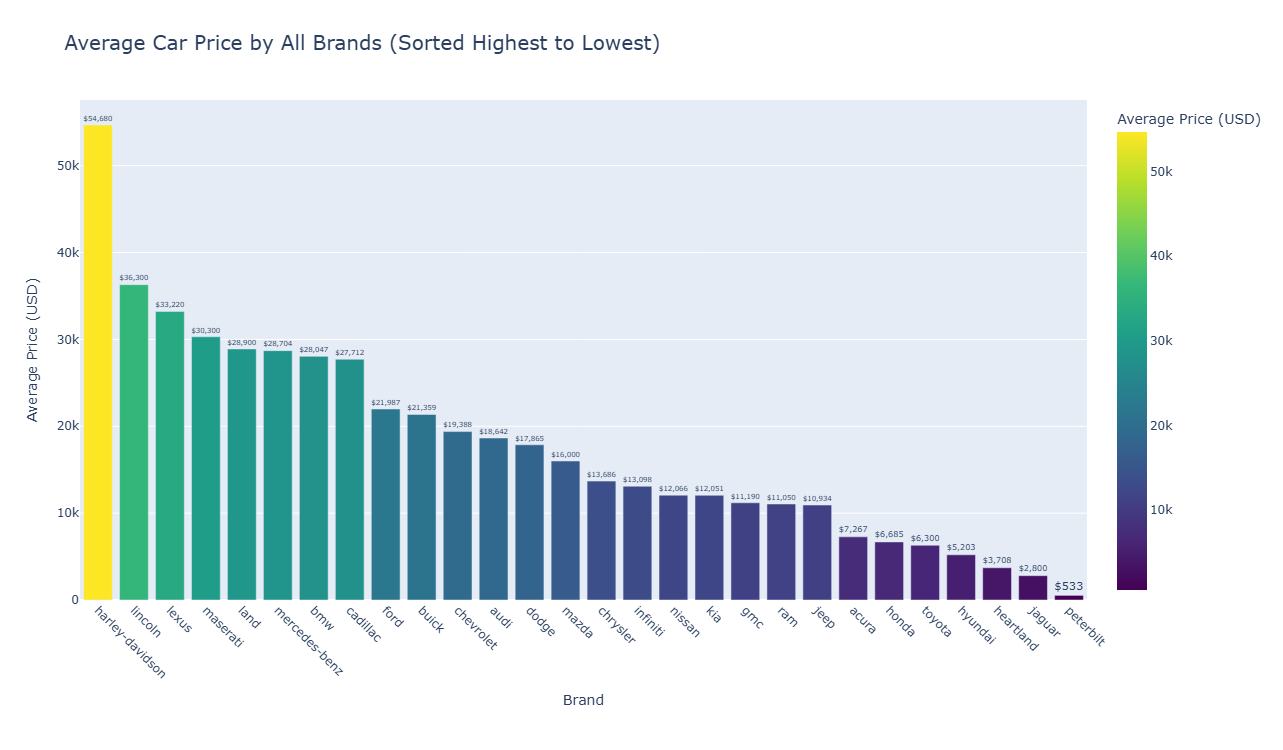

In [22]:
brand_order = cardf.groupby('brand')['price'].median().sort_values(ascending=False).index

fig_box = px.box(
    cardf,
    x='brand',
    y='price',
    color='brand',
    category_orders={'brand': brand_order},   # sorts brands by median price
    title='Car Price Distribution by All Brands (Sorted by Median Price)',
    labels={'brand': 'Brand', 'price': 'Price (USD)'},
    hover_data=['model', 'year', 'mileage', 'Age'],
    points='outliers'
)

fig_box.update_layout(
    height=800,                    # taller to fit all brands
    title_font_size=20,
    xaxis_tickangle=45,            # rotate brand names
    showlegend=False,
    margin=dict(b=150)             # extra bottom margin for long labels
)

fig_box.show()

# === 2. Interactive Bar Chart - Average Price by All Brands (Sorted Highest to Lowest) ===
avg_price_by_brand = (cardf.groupby('brand')['price']
                      .mean()
                      .round(0)
                      .reset_index()
                      .sort_values('price', ascending=False))

fig_bar = px.bar(
    avg_price_by_brand,
    x='brand',
    y='price',
    color='price',
    color_continuous_scale='Viridis',
    title='Average Car Price by All Brands (Sorted Highest to Lowest)',
    labels={'brand': 'Brand', 'price': 'Average Price (USD)'},
    text='price'
)

fig_bar.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig_bar.update_layout(
    height=750,
    xaxis_tickangle=45,
    title_font_size=20,
    margin=dict(b=150)
)

fig_bar.show()

I feel like price by brand is unreliable the brand with the best price is a motorcycle company and jaguar definitly shouldnt be one of the cheapest.

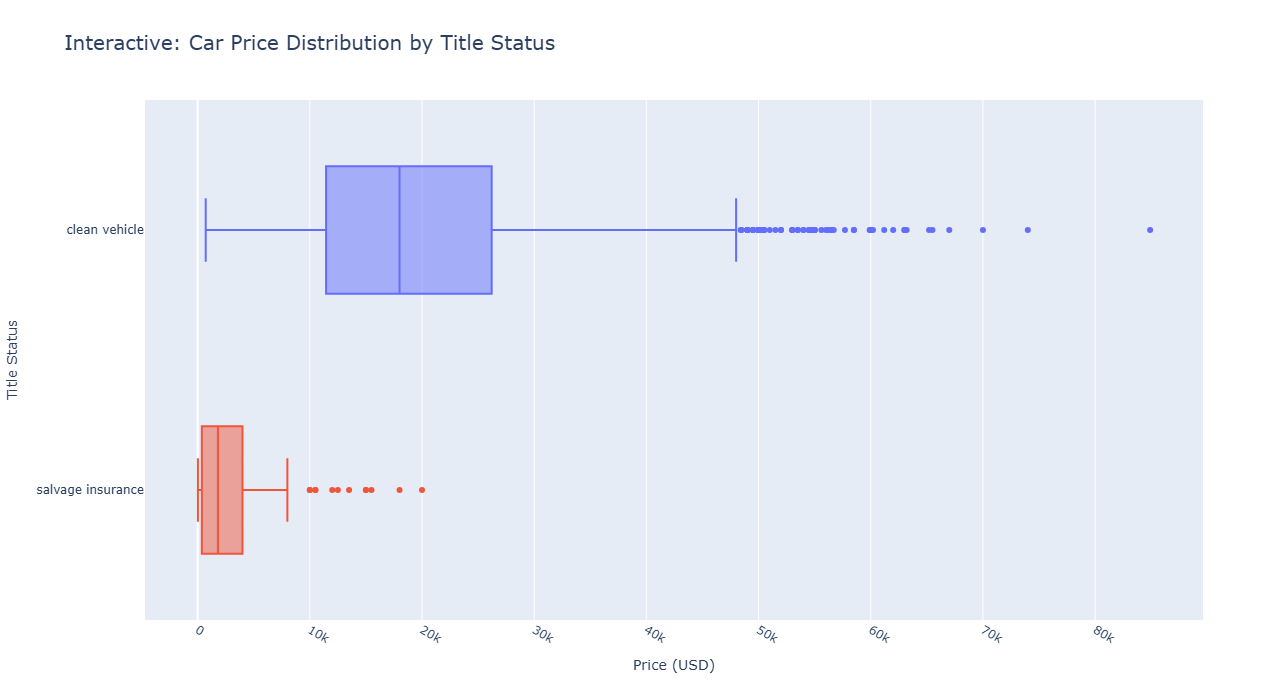

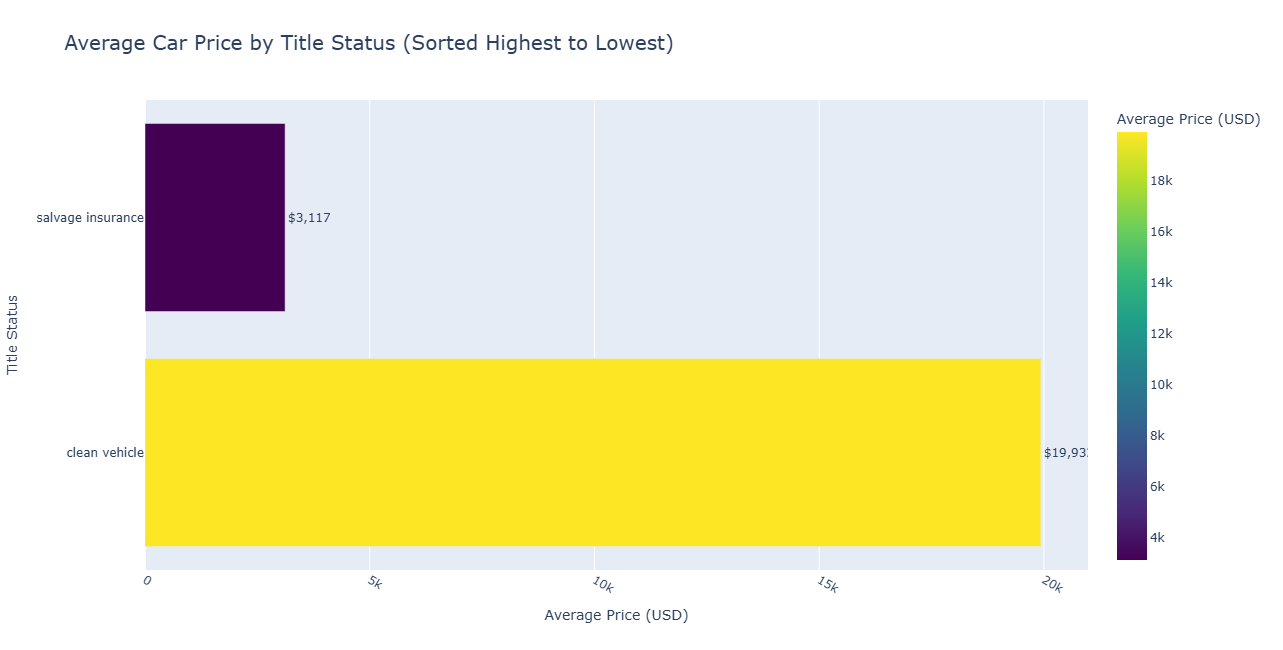

In [24]:
# === 1. Interactive Box Plot by Title Status ===
fig_box = px.box(
    cardf,
    y='title_status',
    x='price',
    color='title_status',
    title='Interactive: Car Price Distribution by Title Status',
    labels={'title_status': 'Title Status', 
            'price': 'Price (USD)'},
    hover_data=['brand', 'model', 'year', 'mileage', 'Age'],
    points='outliers'
)

fig_box.update_layout(
    height=700,
    title_font_size=20,
    xaxis_tickangle=30,
    showlegend=False
)

fig_box.show()

# === 2. Interactive Bar Chart - Average Price by Title Status (Sorted) ===
avg_price_by_title = (cardf.groupby('title_status')['price']
                      .mean()
                      .round(0)
                      .reset_index()
                      .sort_values('price', ascending=False))

fig_bar = px.bar(
    avg_price_by_title,
    y='title_status',
    x='price',
    color='price',
    color_continuous_scale='Viridis',
    title='Average Car Price by Title Status (Sorted Highest to Lowest)',
    labels={'title_status': 'Title Status', 
            'price': 'Average Price (USD)'},
    text='price'
)

fig_bar.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig_bar.update_layout(
    height=650,
    title_font_size=20,
    xaxis_tickangle=30
)

fig_bar.show()

This one seems obvious but cars with a clean title are worth more than those with a salvage title.

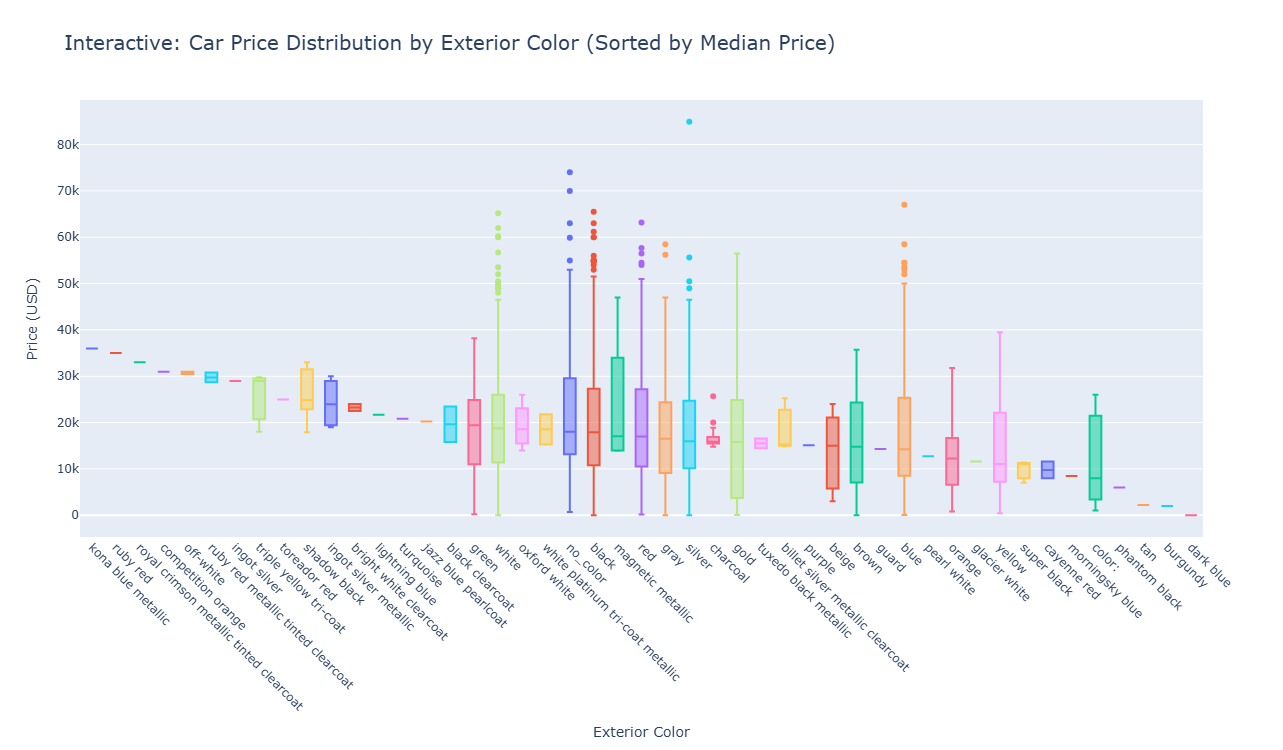

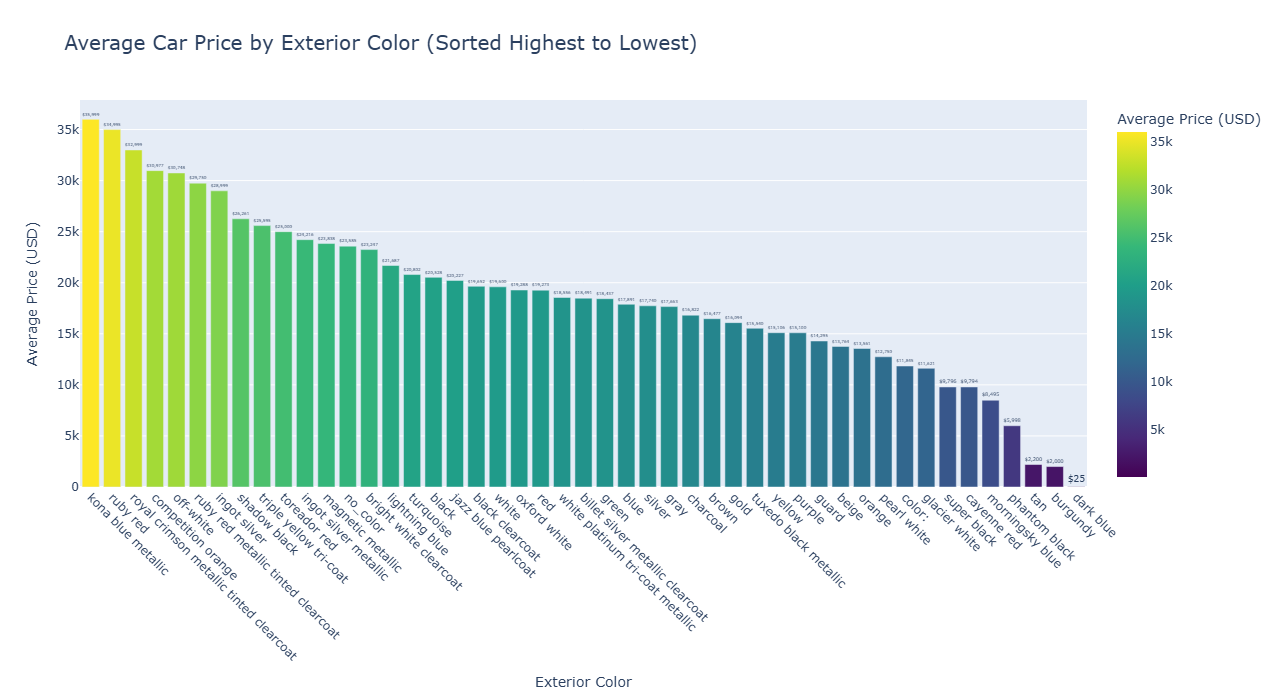

In [25]:
color_order = cardf.groupby('color')['price'].median().sort_values(ascending=False).index

fig_box = px.box(
    cardf,
    x='color',
    y='price',
    color='color',
    category_orders={'color': color_order},   # sorts from most to least expensive
    title='Interactive: Car Price Distribution by Exterior Color (Sorted by Median Price)',
    labels={'color': 'Exterior Color', 
            'price': 'Price (USD)'},
    hover_data=['brand', 'model', 'year', 'mileage', 'Age'],
    points='outliers'
)

fig_box.update_layout(
    height=750,
    title_font_size=20,
    xaxis_tickangle=45,
    showlegend=False,
    margin=dict(b=180)             # extra space for color names
)

fig_box.show()

# === 2. Interactive Bar Chart - Average Price by Color (Sorted) ===
avg_price_by_color = (cardf.groupby('color')['price']
                      .mean()
                      .round(0)
                      .reset_index()
                      .sort_values('price', ascending=False))

fig_bar = px.bar(
    avg_price_by_color,
    x='color',
    y='price',
    color='price',
    color_continuous_scale='Viridis',
    title='Average Car Price by Exterior Color (Sorted Highest to Lowest)',
    labels={'color': 'Exterior Color', 
            'price': 'Average Price (USD)'},
    text='price'
)

fig_bar.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig_bar.update_layout(
    height=700,
    xaxis_tickangle=45,
    title_font_size=20,
    margin=dict(b=180)
)

fig_bar.show()

kona blue metallic is the highest quality color you could put on a car to keep your price high, but magentic metallic looks to hold its value better with slight gains depending on the car.

the best car for value retention would be a magentic metallic Ford, with less than 60k miles, a clean title, and manufactured before 2010